In [165]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', '-q'])
print('imbalanced-learn ready.')

imbalanced-learn ready.


In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [167]:
df = pd.read_csv('data/cleaned_data.csv')
df

,patient_name,age,gender,condition,medication,visit_date,cholesterol,systolic,diastolic,visit_year,visit_month
0,donna hall,51,female,Diabetes,ATORVASTATIN,2021-06-19,207.7,143.0,90.0,2021,6
1,mark young,49,male,Diabetes,METFORMIN,2020-04-06,206.3,109.0,86.0,2020,4
2,lisa young,49,male,Hypertension,NONE,2018-05-23,207.5,153.0,95.0,2018,5
3,daniel robinson,46,male,Asthma,ALBUTEROL,2022-10-10,203.6,127.0,79.0,2022,10
4,robert garcia,49,female,Hypertension,NONE,2018-05-10,199.5,161.0,93.0,2018,5
...,...,...,...,...,...,...,...,...,...,...,...
895,james wilson,58,male,Diabetes,ATORVASTATIN,2020-09-10,228.3,136.0,87.0,2020,9
896,donna martinez,49,female,Heart Disease,LISINOPRIL,2023-03-28,222.7,153.0,88.0,2023,3
897,emily jackson,68,male,Diabetes,ATORVASTATIN,2019-02-21,213.8,153.0,80.0,2019,2
898,robert walker,19,male,Asthma,NONE,2023-04-22,170.0,121.0,70.0,2023,4


## 2. Preprocessing


In [168]:
df_enc = df.copy()
df_enc = df_enc.drop(columns=['patient_name'], errors='ignore')

# visit_year / visit_month already created in loading step
if 'visit_date' in df_enc.columns:
    df_enc['visit_date'] = pd.to_datetime(df_enc['visit_date'], errors='coerce')
    df_enc['visit_year']  = df_enc['visit_date'].dt.year
    df_enc['visit_month'] = df_enc['visit_date'].dt.month
    df_enc = df_enc.drop(columns=['visit_date'])

df_enc = df_enc.fillna(df_enc.median(numeric_only=True))

# Label-encode gender
le_gender = LabelEncoder()
df_enc['gender'] = le_gender.fit_transform(df_enc['gender'])

# One-hot encode medication
medication_dummies = pd.get_dummies(df_enc['medication'], prefix='med')
df_enc = pd.concat([df_enc.drop(columns=['medication']), medication_dummies], axis=1)

print('Columns after encoding:', df_enc.columns.tolist())
print('Any NaN?', df_enc.isnull().any().any())
df_enc.head()


Columns after encoding: ['age', 'gender', 'condition', 'cholesterol', 'systolic', 'diastolic', 'visit_year', 'visit_month', 'med_ALBUTEROL', 'med_ATORVASTATIN', 'med_LISINOPRIL', 'med_METFORMIN', 'med_NONE']
Any NaN? False


,age,gender,condition,cholesterol,systolic,diastolic,visit_year,visit_month,med_ALBUTEROL,med_ATORVASTATIN,med_LISINOPRIL,med_METFORMIN,med_NONE
0,51,0,Diabetes,207.7,143.0,90.0,2021,6,False,True,False,False,False
1,49,1,Diabetes,206.3,109.0,86.0,2020,4,False,False,False,True,False
2,49,1,Hypertension,207.5,153.0,95.0,2018,5,False,False,False,False,True
3,46,1,Asthma,203.6,127.0,79.0,2022,10,True,False,False,False,False
4,49,0,Hypertension,199.5,161.0,93.0,2018,5,False,False,False,False,True


## 3. Train / Test Split

In [169]:
X = df_enc.drop(columns=['condition'])
y = df_enc['condition']

# stratify=y keeps class proportions in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print('Train:', len(X_train), '| Test:', len(X_test))
print('Class distribution (train):')
print(y_train.value_counts())

Train: 720 | Test: 180
Class distribution (train):
condition
Heart Disease    181
Asthma           180
Hypertension     180
Diabetes         179
Name: count, dtype: int64


In [170]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 4. SMOTE — Balance the Training Set

Applied **only to training data** to avoid data leakage. This fixes the core reason all original models defaulted to predicting *Asthma* (the majority class).

In [171]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', dict(y_train.value_counts()))
print('After  SMOTE:', dict(pd.Series(y_train_res).value_counts()))

Before SMOTE: {'Heart Disease': np.int64(181), 'Asthma': np.int64(180), 'Hypertension': np.int64(180), 'Diabetes': np.int64(179)}
After  SMOTE: {'Heart Disease': np.int64(181), 'Asthma': np.int64(181), 'Hypertension': np.int64(181), 'Diabetes': np.int64(181)}


## 5. Model Training

### 5a. Naive Bayes

In [172]:
nb = GaussianNB()
nb.fit(X_train_res, y_train_res)
nb_pred = nb.predict(X_test_scaled)

print('=== Naive Bayes ===')
print('Accuracy:', accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred, zero_division=0))

=== Naive Bayes ===
Accuracy: 0.9444444444444444
               precision    recall  f1-score   support

       Asthma       1.00      1.00      1.00        45
     Diabetes       0.91      0.96      0.93        45
Heart Disease       0.93      0.84      0.88        45
 Hypertension       0.94      0.98      0.96        45

     accuracy                           0.94       180
    macro avg       0.94      0.94      0.94       180
 weighted avg       0.94      0.94      0.94       180



### 5b. Random Forest + GridSearchCV


In [173]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# class_weight removed — SMOTE already balanced the classes
# Adding more estimators and min_samples_leaf to reduce overfitting
rf_params = {
    'n_estimators':      [200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1
)
rf_gs.fit(X_train_res, y_train_res)

best_rf = rf_gs.best_estimator_
rf_pred = best_rf.predict(X_test_scaled)

print('Best RF params:', rf_gs.best_params_)
print('\n=== Random Forest (improved) ===')
print('Accuracy:', accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, zero_division=0))


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}

=== Random Forest (improved) ===
Accuracy: 0.9388888888888889
               precision    recall  f1-score   support

       Asthma       1.00      1.00      1.00        45
     Diabetes       0.92      0.98      0.95        45
Heart Disease       0.93      0.82      0.87        45
 Hypertension       0.91      0.96      0.93        45

     accuracy                           0.94       180
    macro avg       0.94      0.94      0.94       180
 weighted avg       0.94      0.94      0.94       180



### 5c. SVM + GridSearchCV


In [174]:




# class_weight removed — SMOTE already balanced the classes
svm_params = {
    'C':      [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
}

svm_gs = GridSearchCV(
    SVC(random_state=42, probability=True),
    svm_params, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1
)
svm_gs.fit(X_train_res, y_train_res)

best_svm = svm_gs.best_estimator_
svm_pred = best_svm.predict(X_test_scaled)

print('Best SVM params:', svm_gs.best_params_)
print('\n=== SVM (improved) ===')
print('Accuracy:', accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred, zero_division=0))


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best SVM params: {'C': 10, 'kernel': 'linear'}

=== SVM (improved) ===
Accuracy: 0.9277777777777778
               precision    recall  f1-score   support

       Asthma       0.94      1.00      0.97        45
     Diabetes       0.91      0.96      0.93        45
Heart Disease       0.91      0.87      0.89        45
 Hypertension       0.95      0.89      0.92        45

     accuracy                           0.93       180
    macro avg       0.93      0.93      0.93       180
 weighted avg       0.93      0.93      0.93       180



### 5d. Gradient Boosting + GridSearchCV (new model)

In [175]:
gb_params = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 5],
    'subsample':     [0.8, 1.0],
}

gb_gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1
)
gb_gs.fit(X_train_res, y_train_res)

best_gb = gb_gs.best_estimator_
gb_pred = best_gb.predict(X_test_scaled)

print('Best GB params:', gb_gs.best_params_)
print('\n=== Gradient Boosting ===')
print('Accuracy:', accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred, zero_division=0))


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best GB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}

=== Gradient Boosting ===
Accuracy: 0.9444444444444444
               precision    recall  f1-score   support

       Asthma       0.96      1.00      0.98        45
     Diabetes       0.92      0.98      0.95        45
Heart Disease       0.95      0.87      0.91        45
 Hypertension       0.95      0.93      0.94        45

     accuracy                           0.94       180
    macro avg       0.94      0.94      0.94       180
 weighted avg       0.94      0.94      0.94       180



### 5e. Voting Ensemble (RF + SVM + GB)

In [176]:
voting_clf = VotingClassifier(
    estimators=[
        ('rf',  best_rf),
        ('svm', best_svm),
        ('gb',  best_gb),
    ],
    voting='soft',
)
voting_clf.fit(X_train_res, y_train_res)
vote_pred = voting_clf.predict(X_test_scaled)

print('=== Voting Ensemble ===')
print('Accuracy:', accuracy_score(y_test, vote_pred))
print(classification_report(y_test, vote_pred, zero_division=0))

=== Voting Ensemble ===
Accuracy: 0.9444444444444444
               precision    recall  f1-score   support

       Asthma       0.98      1.00      0.99        45
     Diabetes       0.90      0.98      0.94        45
Heart Disease       0.93      0.87      0.90        45
 Hypertension       0.98      0.93      0.95        45

     accuracy                           0.94       180
    macro avg       0.95      0.94      0.94       180
 weighted avg       0.95      0.94      0.94       180



## 6. Accuracy Comparison

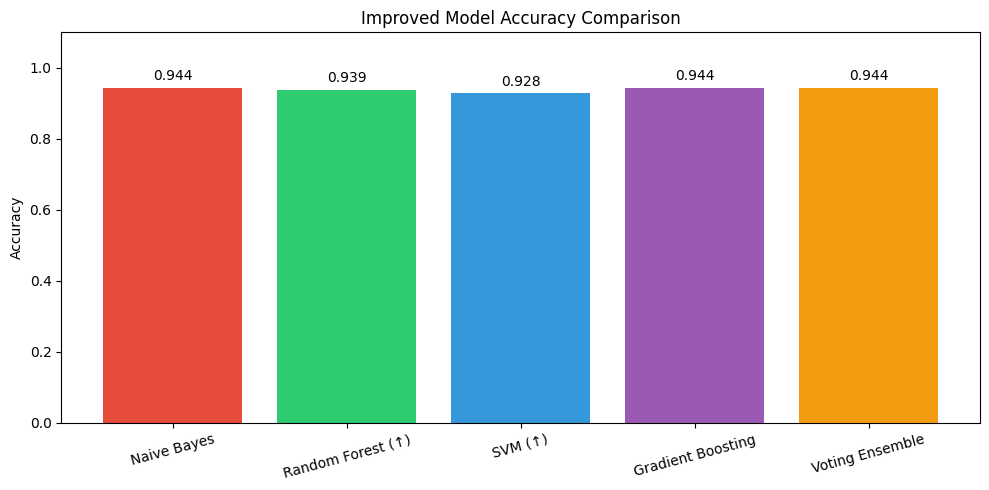

In [177]:
models = {
    'Naive Bayes':       nb_pred,
    'Random Forest (↑)': rf_pred,
    'SVM (↑)':           svm_pred,
    'Gradient Boosting': gb_pred,
    'Voting Ensemble':   vote_pred,
}

accuracies = {name: accuracy_score(y_test, pred) for name, pred in models.items()}

plt.figure(figsize=(10, 5))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12']
bars = plt.bar(accuracies.keys(), accuracies.values(), color=colors)
plt.ylim(0, 1.1)
plt.title('Improved Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
for bar, acc in zip(bars, accuracies.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f'{acc:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('data/improved_model_comparison.png')
plt.show()

## 7. Confusion Matrices

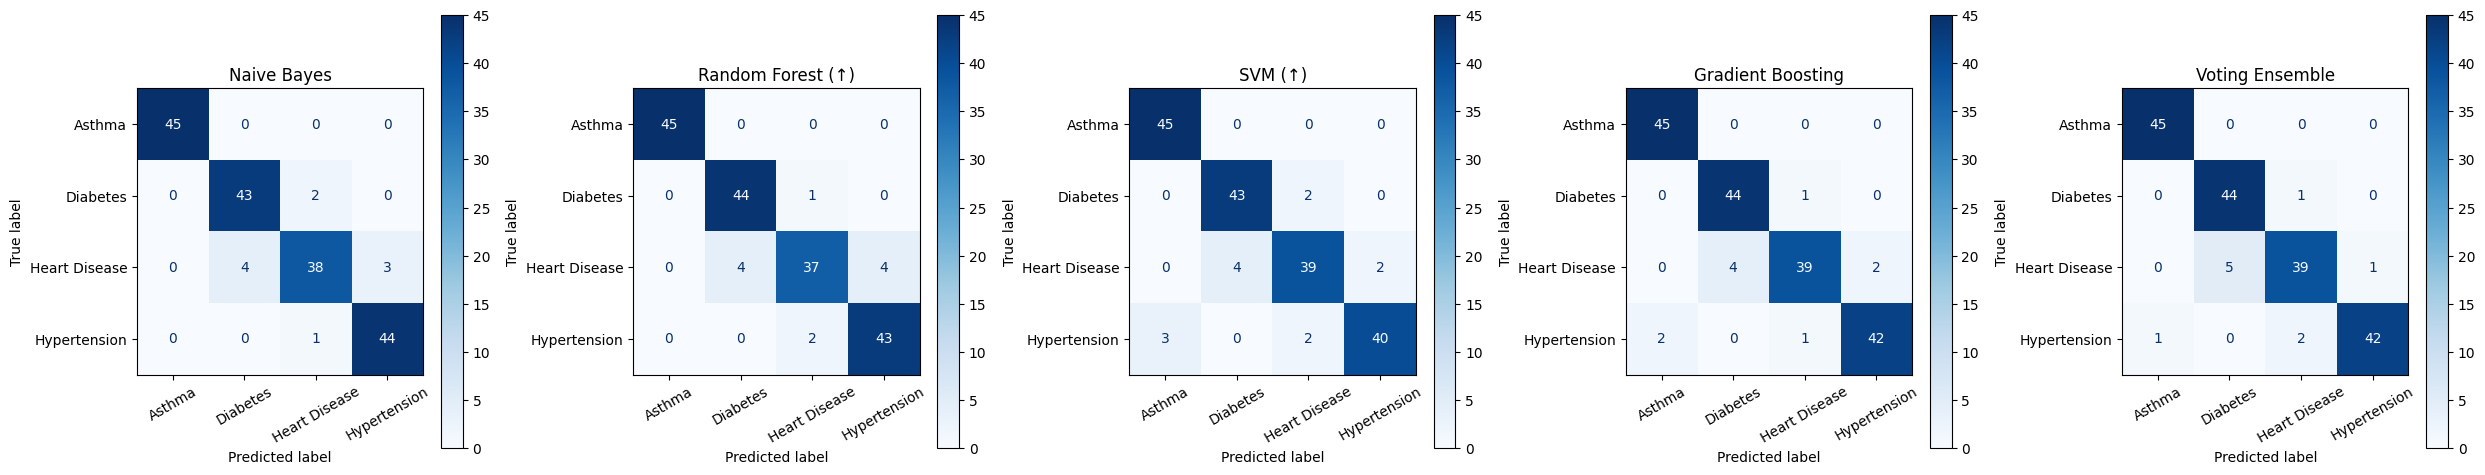

In [178]:
labels = sorted(y.unique())
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 5))

for ax, (name, pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap='Blues')
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('data/improved_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 8. Feature Importance (Random Forest)

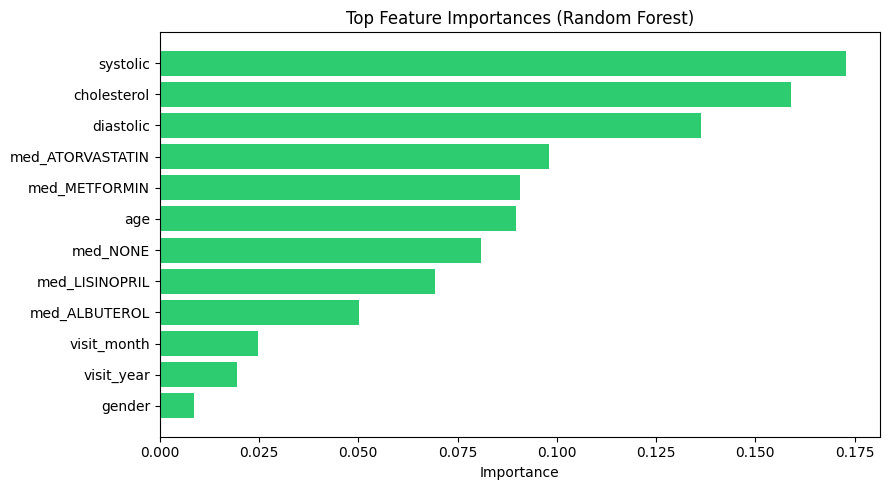

,feature,importance
3,systolic,0.172760
2,cholesterol,0.159081
4,diastolic,0.136431
8,med_ATORVASTATIN,0.098040
10,med_METFORMIN,0.090623
0,age,0.089759
11,med_NONE,0.080868
9,med_LISINOPRIL,0.069233
7,med_ALBUTEROL,0.050306
6,visit_month,0.024798


In [179]:
importances = best_rf.feature_importances_
feat_df = pd.DataFrame({'feature': X.columns, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(feat_df['feature'][:15], feat_df['importance'][:15], color='#2ecc71')
plt.xlabel('Importance')
plt.title('Top Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('data/feature_importance.png')
plt.show()

feat_df.head(10)

## 9. Save Results

In [180]:
results_df = pd.DataFrame({'actual': y_test.values})
for name, pred in models.items():
    col = name.replace(' ', '_').replace('(↑)', 'improved').replace('(', '').replace(')', '')
    results_df[col] = pred

results_df.to_csv('data/improved_classification_results.csv', index=False)
print('Saved to data/improved_classification_results.csv')
results_df.head(10)

Saved to data/improved_classification_results.csv


,actual,Naive_Bayes,Random_Forest_improved,SVM_improved,Gradient_Boosting,Voting_Ensemble
0,Asthma,Asthma,Asthma,Asthma,Asthma,Asthma
1,Diabetes,Diabetes,Diabetes,Diabetes,Diabetes,Diabetes
2,Heart Disease,Heart Disease,Heart Disease,Heart Disease,Heart Disease,Heart Disease
3,Heart Disease,Heart Disease,Heart Disease,Heart Disease,Heart Disease,Heart Disease
4,Asthma,Asthma,Asthma,Asthma,Asthma,Asthma
5,Asthma,Asthma,Asthma,Asthma,Asthma,Asthma
6,Diabetes,Diabetes,Diabetes,Diabetes,Diabetes,Diabetes
7,Hypertension,Hypertension,Hypertension,Hypertension,Hypertension,Hypertension
8,Diabetes,Diabetes,Diabetes,Diabetes,Diabetes,Diabetes
9,Heart Disease,Heart Disease,Hypertension,Heart Disease,Hypertension,Heart Disease


## 10. Predict New Patients

In [181]:
def predict_patient(age, gender, medication, cholesterol, systolic, diastolic,
                    visit_year, visit_month):
    g = le_gender.transform([gender])[0]

    row = {
        'age': age, 'gender': g, 'cholesterol': cholesterol,
        'systolic': systolic, 'diastolic': diastolic,
        'visit_year': visit_year, 'visit_month': visit_month
    }

    # One-hot medication columns
    all_meds = [c.replace('med_', '') for c in X.columns if c.startswith('med_')]
    for med in all_meds:
        row[f'med_{med}'] = 1 if medication == med else 0

    data = pd.DataFrame([row])[X.columns]   # ensure column order matches training
    data_scaled = scaler.transform(data)

    print(f"\nPatient: Age={age}, Gender={gender}, Medication={medication}, BP={systolic}/{diastolic}")
    for name, model in [
        ('Naive Bayes',       nb),
        ('Random Forest (↑)', best_rf),
        ('SVM (↑)',           best_svm),
        ('Gradient Boosting', best_gb),
        ('Voting Ensemble',   voting_clf),
    ]:
        print(f'  {name:<22} → {model.predict(data_scaled)[0]}')
    print('-' * 50)


predict_patient(45, 'male',   'METFORMIN', 220, 135, 85, 2023, 5)
predict_patient(30, 'female', 'ALBUTEROL', 160, 110, 70, 2022, 3)
predict_patient(60, 'other',  'NONE',      240, 150, 95, 2021, 8)


Patient: Age=45, Gender=male, Medication=METFORMIN, BP=135/85
  Naive Bayes            → Diabetes
  Random Forest (↑)      → Diabetes
  SVM (↑)                → Diabetes
  Gradient Boosting      → Diabetes
  Voting Ensemble        → Diabetes
--------------------------------------------------

Patient: Age=30, Gender=female, Medication=ALBUTEROL, BP=110/70
  Naive Bayes            → Asthma
  Random Forest (↑)      → Asthma
  SVM (↑)                → Asthma
  Gradient Boosting      → Asthma
  Voting Ensemble        → Asthma
--------------------------------------------------

Patient: Age=60, Gender=other, Medication=NONE, BP=150/95
  Naive Bayes            → Hypertension
  Random Forest (↑)      → Hypertension
  SVM (↑)                → Hypertension
  Gradient Boosting      → Heart Disease
  Voting Ensemble        → Hypertension
--------------------------------------------------
